## Who Worked On This Part?
Muhammad Azaam Ali: made the train/validation/test split that every model uses, and trained the first quick model (logistic regression).

# Predicting Models

In this notebook we:
1. split the cleaned data once into **train, validation and test**, and save the three parts so every model (PyCaret, the tuned models and the AWS model) uses exactly the same rows,
2. train a **quick first model**, logistic regression. It won't be the best, but it lets the deployment team start building the API and web page while we keep improving the model.

We predict `is_poisonous` (1 = poisonous, 0 = edible). The most important metric is **recall on poisonous**: of all the poisonous mushrooms, how many does the model catch? Calling a poisonous mushroom edible is the dangerous mistake. Next to that we use **ROC-AUC**: how well the model ranks poisonous mushrooms above edible ones, without depending on a threshold.

# How we are approaching this
We are dividing the clean data into **70/15/15** split. 70% for training and used to help model to learn about underlying patters and relationships in data, 15% for validation used for fine tuning hyperparameters and detect overfitting, and 15% for testing is kept hidden until the very end to see unbiased results of our training models.
We will be starting with Logisticregression because it is simple and easy to explain and gives baseline to beat while working side by side on other models and fine-tuning.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# walk up from where the notebook runs to the repo root, so the data path works on every machine
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'MUSHROOM' / 'datasets').is_dir())
DATA = ROOT / 'Mushroom' / 'datasets'

raw = pd.read_csv(DATA / 'mushroom_clean.csv')
df = raw.copy()
df.shape

num_cols= ['cap_diameter_cm', 'stem_height_cm', 'stem_width_mm']
# all columns except for is_poisonous and the numeric columns
cat_cols = [c for c in df.columns if c != 'is_poisonous' and c not in num_cols ]
print(cat_cols)
df.dtypes

['spore_print_color', 'gill_color', 'habitat', 'season', 'ring_type', 'cap_shape', 'stem_surface']


cap_diameter_cm      float64
stem_height_cm       float64
stem_width_mm        float64
spore_print_color        str
gill_color               str
habitat                  str
season                   str
ring_type                str
cap_shape                str
stem_surface             str
is_poisonous           int64
dtype: object

The train_test_split splits the dataframe in 2 parts one time. so we are using twice the spltis to get our desired results. First split splits the data into 70/30 part. 30 part is kept away for further use. stratify keeps 38% poisonous in every part, and random_state gives the same split every run. In the second split the 30 part is further divided into 50/50 which when broken down comes to 15 each.

In [54]:
# splitting into 70/15/15 train/val/test splits
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['is_poisonous']
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['is_poisonous']
)
print(train_df.shape, val_df.shape, test_df.shape)
print(train_df['is_poisonous'].mean(), val_df['is_poisonous'].mean(), test_df['is_poisonous'].mean())
train_df.to_csv(DATA / 'train.csv', index=False)
val_df.to_csv(DATA / 'val.csv', index=False)
test_df.to_csv(DATA / 'test.csv', index=False)

(3500, 11) (750, 11) (750, 11)
0.37857142857142856 0.37866666666666665 0.37866666666666665


Before modeling anything it is a industry practice to see what the dummy classifier model gives as an output, and we compare its results to our models. if the difference is high enough that means our model is beating the bare minimum. We are using most_frequent in strategy that predicts the class that always appear most often in the training set. We are interested in seeing in Accuracy which is the share of all predictions that are right and Recall which is the share of the poisonous mushrooms that the model catches.

In training, validating, and testing we are dropping the poisonous table so the model can't see the answer, and y column becomes what the model has to predict.

In [55]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score

X_train, y_train = train_df.drop(columns='is_poisonous'), train_df['is_poisonous']
X_val, y_val = val_df.drop(columns='is_poisonous'), val_df['is_poisonous']
X_test, y_test = test_df.drop(columns='is_poisonous'), test_df['is_poisonous']

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_predict = dummy.predict(X_val)
accuracy = accuracy_score(y_val, y_predict) # accuracy is the proportion of correct predictions (both true positives and true negatives) out of all predictions
recall = recall_score(y_val, y_predict) # recall is the proportion of actual positives that were correctly identified
accuracy, recall

(0.6213333333333333, 0.0)

The result shows that the dummy model gotten every possible edible mushroom right as that class makes 62 percent of the trained data, but it was unable to catch a single poisonous mushroom. Now the model we make should display better results than the dummy classifier.

# Making Models

## Logistic Regression

In [56]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

onc = OneHotEncoder(handle_unknown='ignore')

# demo = OneHotEncoder(sparse_output=False)
# demo.fit(X_train[['habitat']])                        # learns which habitats exist, from train only
# print(demo.categories_)                               # the values it found
# print(X_train[['habitat']].head(3))
# print(demo.transform(X_train[['habitat']].head(3)))   # each row becomes 0s and a single 1

print(X_train[cat_cols].nunique())
print()
ct = ColumnTransformer([
    ("onc", onc, cat_cols),
    ("num", make_pipeline(FunctionTransformer(np.log1p), StandardScaler()), num_cols)
])

print(ct)


spore_print_color     8
gill_color           13
habitat               9
season                5
ring_type             9
cap_shape             8
stem_surface          9
dtype: int64

ColumnTransformer(transformers=[('onc', OneHotEncoder(handle_unknown='ignore'),
                                 ['spore_print_color', 'gill_color', 'habitat',
                                  'season', 'ring_type', 'cap_shape',
                                  'stem_surface']),
                                ('num',
                                 Pipeline(steps=[('functiontransformer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['cap_diameter_cm', 'stem_height_cm',
                                  'stem_width_mm'])])


In [57]:
X_train_ready = ct.fit_transform(X_train)
print(X_train_ready.shape)


(3500, 64)


## Step 1: the full pipeline
`ct` only prepares the data. Here we put `ct` and the model together in one `Pipeline`:
1. `prep`: the ColumnTransformer (one-hot for the categories, log1p + scaling for the numbers)
2. `logreg`: the logistic regression

`fit(X_train, y_train)` runs both steps on the training data only. Because the preparation is inside the pipeline, val, test and later new mushrooms from the web app are prepared with exactly the same rules automatically.

In [58]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ('prep', ct),
    ('logreg', LogisticRegression(max_iter=1000)),  # max_iter: more rounds so the solver finishes learning
])

logreg.fit(X_train, y_train)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\azaam\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\sklearn\\utils\\_repr_html\\estimator.js'

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\azaam\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\sklearn\\utils\\_repr_html\\estimator.js'

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('onc',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['spore_print_color',
                                                   'gill_color', 'habitat',
                                                   'season', 'ring_type',
                                                   'cap_shape',
                                                   'stem_surface']),
                                                 ('num',
                                                  Pipeline(steps=[('functiontransformer',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                          

## Step 2: scores on train and validation
`predict_proba` gives the chance of being poisonous for every mushroom. A mushroom counts as poisonous when that chance is 0.5 or more.

We score the same model on train and on validation, next to the dummy:
- if train is much better than validation, the model is overfitting (it memorised the training rows)
- the model has to beat the dummy, especially on recall

In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, f1_score

def evaluate(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        'roc_auc': roc_auc_score(y_true, proba),
        'recall': recall_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),  # dummy never predicts poisonous: 0/0 becomes 0
        'f1': f1_score(y_true, pred),
        'accuracy': accuracy_score(y_true, pred),
    }

scores = pd.DataFrame({
    'dummy (val)': evaluate(y_val, dummy.predict_proba(X_val)[:, 1]),
    'logreg (train)': evaluate(y_train, logreg.predict_proba(X_train)[:, 1]),
    'logreg (val)': evaluate(y_val, logreg.predict_proba(X_val)[:, 1]),
}).T.round(3)
scores

,roc_auc,recall,precision,f1,accuracy
dummy (val),0.500,0.000,0.000,0.000,0.621
logreg (train),0.565,0.032,0.597,0.062,0.625
logreg (val),0.491,0.028,0.500,0.053,0.621


## Step 3: confusion matrix on validation
Shows the 4 possible outcomes. Rows are the real class, columns what the model predicted. The most important cell is **bottom-left**: poisonous mushrooms the model called edible.

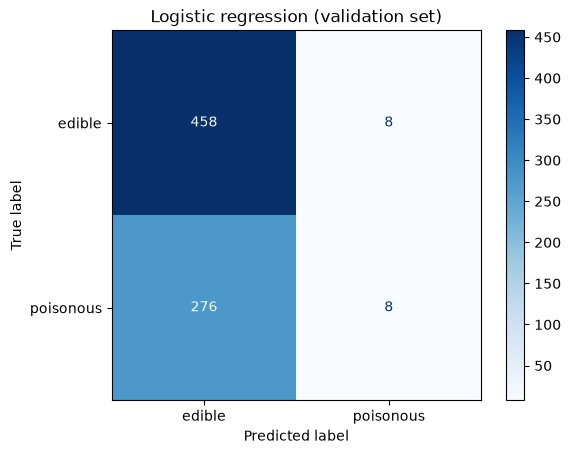

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_val, logreg.predict(X_val), display_labels=['edible', 'poisonous'], cmap='Blues')
plt.title('Logistic regression (validation set)')
plt.show()

### What this tells us
*(to write: is the model overfitting? does it beat the dummy? what does recall 0.39 mean in plain words? why might a linear model struggle here?)*

# Improving the model

## Step 4: class weights
Only 38% of the training mushrooms are poisonous, so the model learns more from edible ones and leans towards saying "edible".

`class_weight='balanced'` makes every mistake on a poisonous mushroom count more (about 62/38 = 1.6 times as much as a mistake on an edible one). The model then leans towards catching poisonous mushrooms. Everything else stays the same, so we can see the effect of only this change.

In [ ]:
logreg_balanced = Pipeline([
    ('prep', ct),
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced')),
])
logreg_balanced.fit(X_train, y_train)

scores = pd.DataFrame({
    'logreg (val)': evaluate(y_val, logreg.predict_proba(X_val)[:, 1]),
    'logreg balanced (val)': evaluate(y_val, logreg_balanced.predict_proba(X_val)[:, 1]),
}).T.round(3)
scores

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_val, logreg_balanced.predict(X_val), display_labels=['edible', 'poisonous'], cmap='Blues')
plt.title('Logistic regression, balanced (validation set)')
plt.show()

### What this tells us
*(to write: what happened to recall, precision and accuracy? why did ROC-AUC stay exactly the same? which mistake did we trade for which?)*

## Step 5: tune C
`C` controls **regularisation**: how strongly the model is held back from giving features big weights.
- small `C` = strong brake: simple model, less risk of overfitting
- big `C` = weak brake: the model follows the training data more closely

`GridSearchCV` tries every value in the list with 5-fold cross-validation **on the training data only** and keeps the one with the best ROC-AUC. We tune on AUC because it doesn't depend on the threshold. Validation stays untouched until we score the winner.

The name `logreg__C` means: the parameter `C` of the pipeline step called `logreg`.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    logreg_balanced,
    param_grid={'logreg__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
    cv=cv,
    scoring='roc_auc',
)
grid.fit(X_train, y_train)

# mean AUC over the 5 folds for every C, and how much it varies between folds
pd.DataFrame(grid.cv_results_)[['param_logreg__C', 'mean_test_score', 'std_test_score']].round(3)

In [ ]:
logreg_tuned = grid.best_estimator_
print('best C:', grid.best_params_['logreg__C'])

scores = pd.DataFrame({
    'logreg (val)': evaluate(y_val, logreg.predict_proba(X_val)[:, 1]),
    'logreg balanced (val)': evaluate(y_val, logreg_balanced.predict_proba(X_val)[:, 1]),
    'logreg balanced + tuned C (val)': evaluate(y_val, logreg_tuned.predict_proba(X_val)[:, 1]),
}).T.round(3)
scores

### What this tells us
*(to write: how much does AUC change between the C values? is the best C really better than C=1, compared to the std between folds? what does that say about the limits of logistic regression on this data?)*

## Step 6: save the model
We save the whole pipeline (preparation + model) with `joblib`. The deployment team can load this one file in the API and give it a raw mushroom; the pipeline does the one-hot encoding and scaling itself. The compare notebook also loads it to compare it with the other models.

In [ ]:
import joblib

MODELS = ROOT / 'Mushroom' / 'models'
MODELS.mkdir(exist_ok=True)
joblib.dump(logreg_tuned, MODELS / 'logreg.pkl')

## Conclusion
*(to write: what was the baseline, what did each improvement do, and why do we move on to tree models)*